# Checking correlation

In [1]:
from utils_3 import PairwiseData, Population

In [2]:
# import os

# os.environ["HF_HOME"] = "/home/jennifer/scratch/hf_datasets_cache"
# os.environ["HF_HUB_CACHE"] = "/home/jennifer/scratch/hf_datasets_cache"
# os.environ["HF_DATASETS_CACHE"] = "/home/jennifer/scratch/hf_datasets_cache"

In [3]:
import os
for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


In [ ]:
from datasets import load_dataset

ds = load_dataset(
    "lmarena-ai/arena-human-preference-140k") 
ds = dict(ds)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
pw = PairwiseData(ds, M=30, N=30)

In [6]:
population = Population(pw)

100%|██████████| 30/30 [00:01<00:00, 15.40it/s]


30


/tmp/ipykernel_3978789/2072635279.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


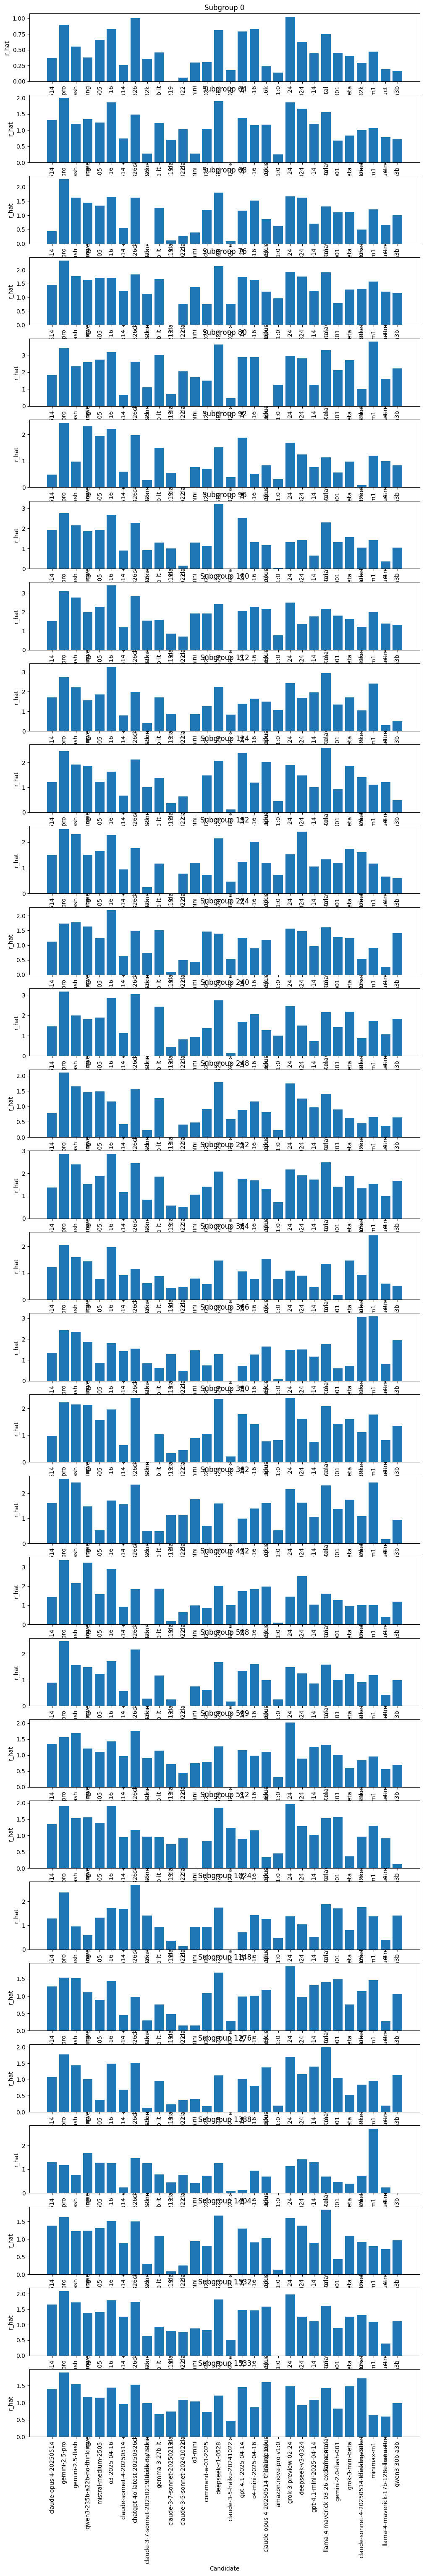

In [7]:
import numpy as np
import matplotlib.pyplot as plt

num_subgroups, num_candidates = population.population_utilities.shape
print(num_subgroups)
fig, axes = plt.subplots(num_subgroups, 1, figsize=(12, max(3, 2.5 * num_subgroups)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    subgroup = population.idx_to_subgroup[row_idx]
    r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


## Plotting the candidate distributions

In [8]:
pw.candidate_distr

array([0.04811053, 0.0455991 , 0.04537616, 0.04260244, 0.04232048,
       0.04203852, 0.03987463, 0.03695009, 0.03504193, 0.0344649 ,
       0.03350754, 0.03314033, 0.03152069, 0.03138955, 0.03136332,
       0.03077972, 0.03053055, 0.03048465, 0.03004531, 0.0300322 ,
       0.0290814 , 0.02855026, 0.02850436, 0.02828141, 0.02822895,
       0.02819617, 0.02704209, 0.02604539, 0.02557327, 0.02532409])

/tmp/ipykernel_3978789/275064710.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


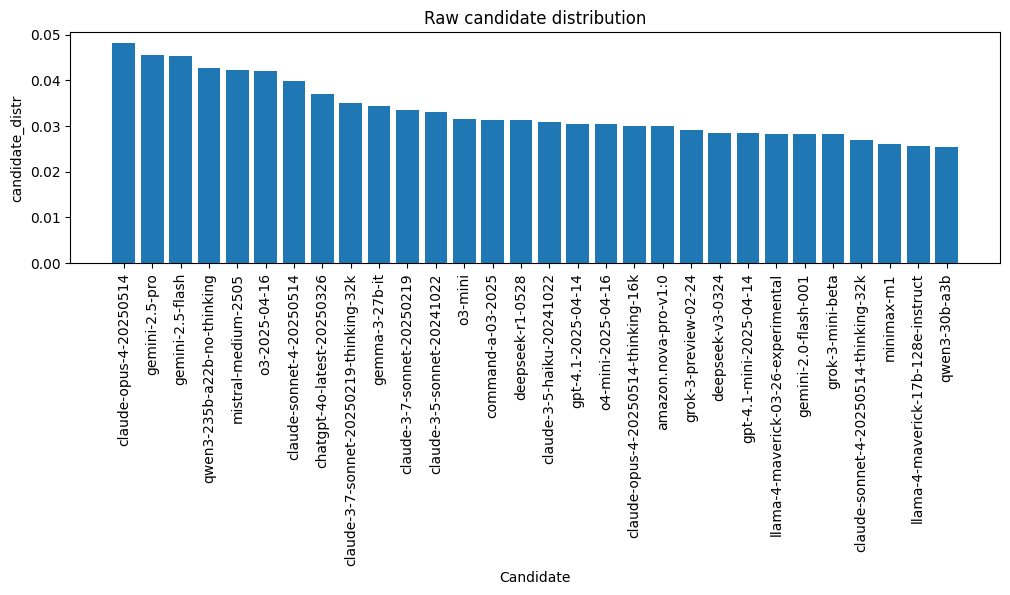

In [9]:
num_subgroups, num_candidates = population.population_utilities.shape
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    # subgroup = population.idx_to_subgroup[row_idx]
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), pw.candidate_distr)
    ax.set_title(f'Raw candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [10]:
pw.candidate_distr.sum()

np.float64(0.9999999999999999)

The empirical distribution does sum to 1.0, approximately, which is what I would expect.

In [11]:
pw.winners.shape

(37454,)

In [12]:
conditional_candidate_idx = 0
conditional_idxs = (pw.winners == conditional_candidate_idx) | (pw.losers == conditional_candidate_idx)

In [13]:
conditional_candidates = np.where(
    pw.winners[conditional_idxs] == conditional_candidate_idx,
    pw.losers[conditional_idxs],
    pw.winners[conditional_idxs],
)

In [14]:
candidates, counts = np.unique(
    conditional_candidates,
    return_counts=True
)

all_conditional_distr = np.zeros_like(pw.candidate_distr)
all_conditional_distr[candidates] = counts / counts.sum()

/tmp/ipykernel_3978789/1330237316.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


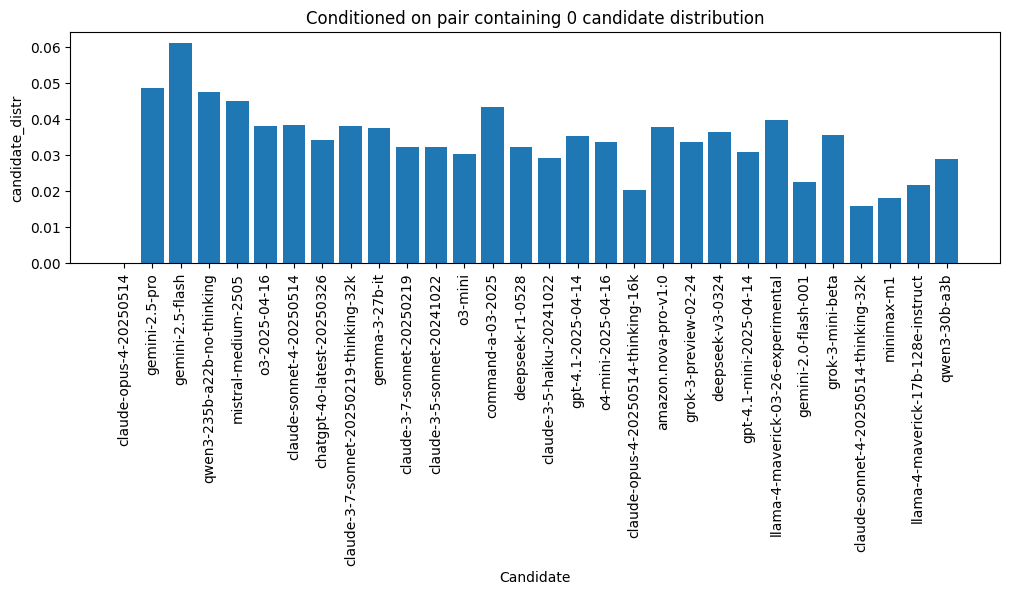

In [15]:
conditional_candidate_distr = counts / counts.sum()

num_candidates = len(all_conditional_distr)
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    # subgroup = population.idx_to_subgroup[row_idx]
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), all_conditional_distr)
    ax.set_title(f'Conditioned on pair containing {conditional_candidate_idx} candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


1.0
1.0
1.0
1.0
0.9999999999999999
1.0
1.0000000000000002
0.9999999999999999
1.0000000000000002
1.0


/tmp/ipykernel_3978789/3784681178.py:41: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


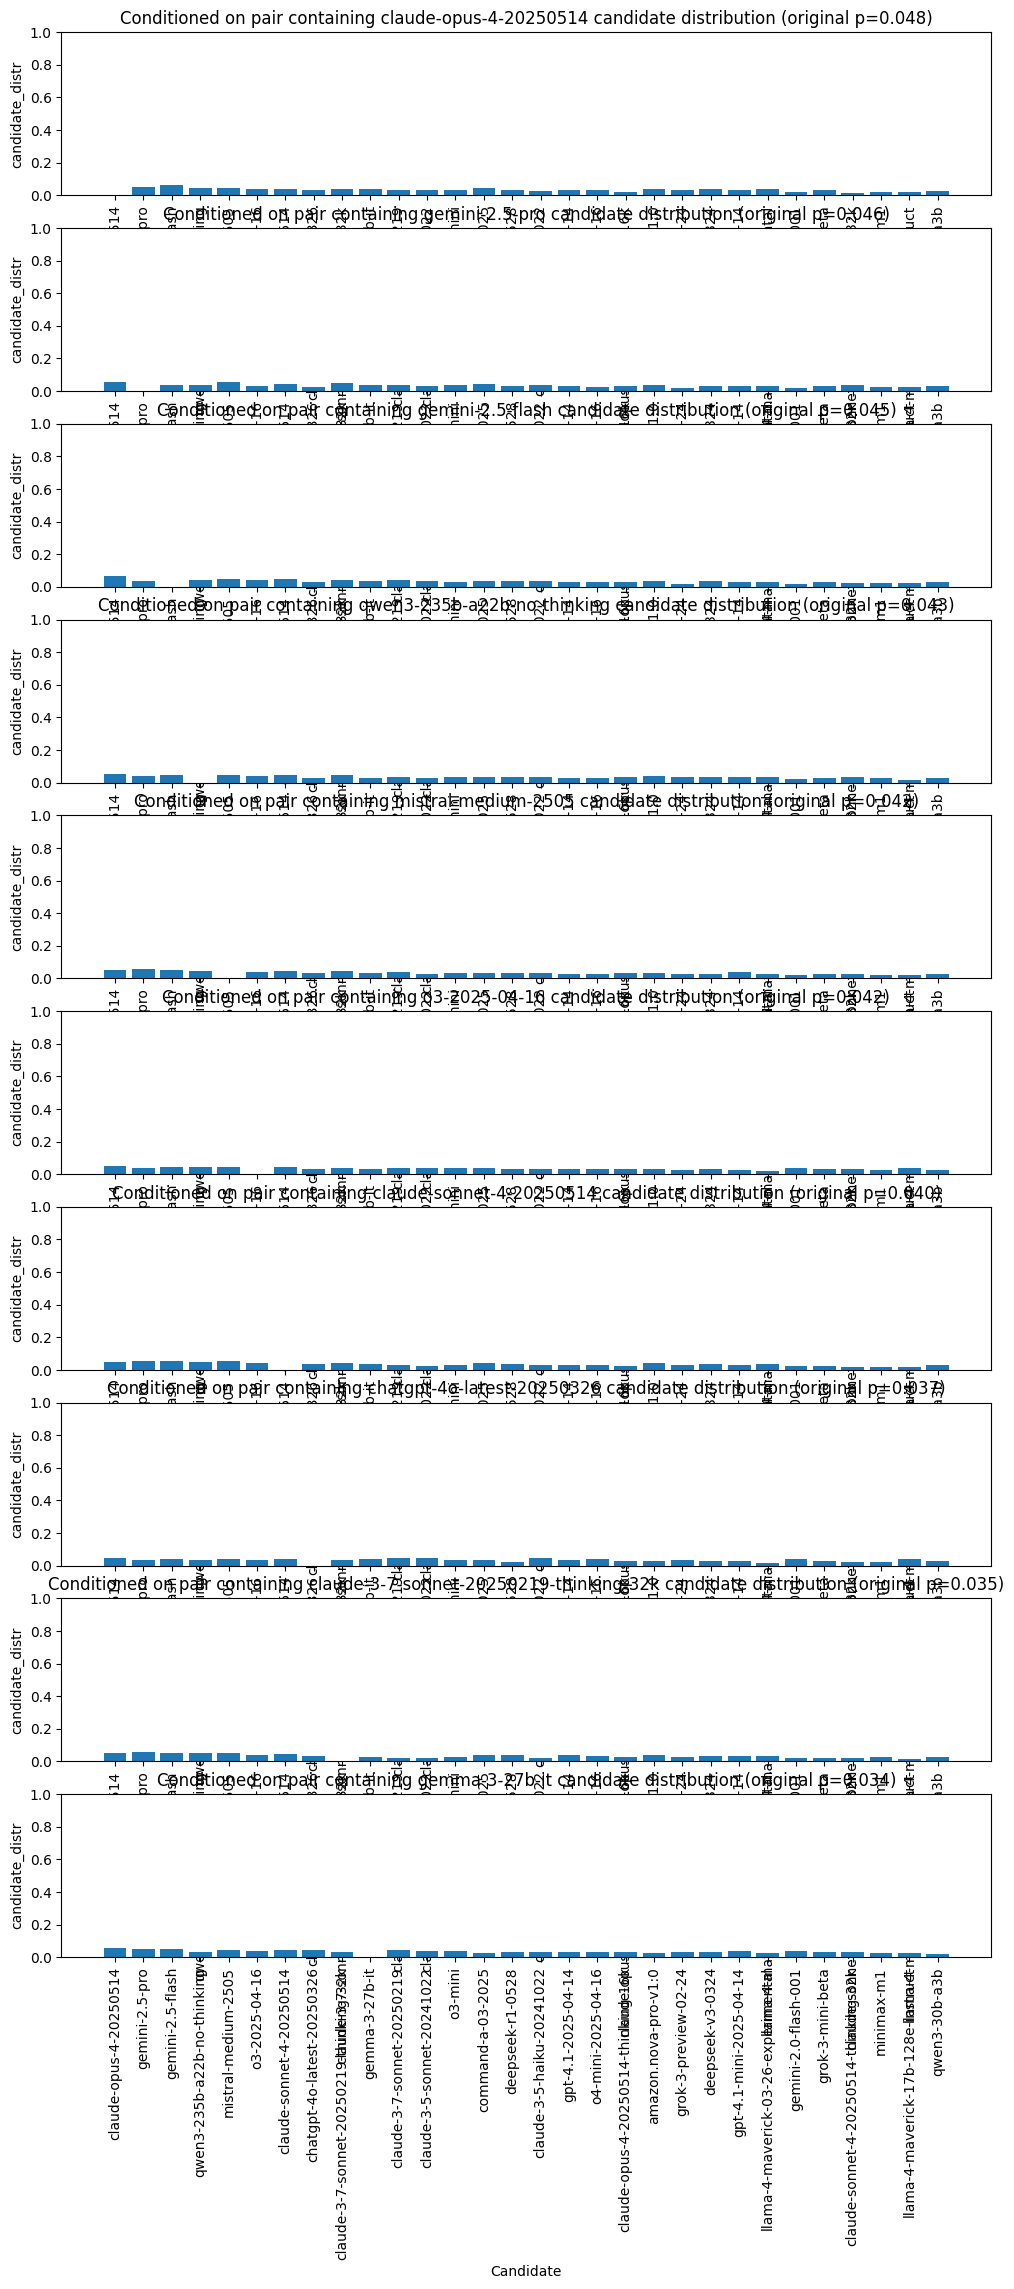

In [16]:
candidate_distribution = getattr(pw, 'candidate_distribution', pw.candidate_distr)
top_candidate_idxs = np.argsort(candidate_distribution)[-10:][::-1]

num_candidates = len(candidate_distribution)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]
top_candidate_labels = [pw.idx_to_candidates[i] for i in top_candidate_idxs]

fig, axes = plt.subplots(
    len(top_candidate_idxs),
    1,
    figsize=(12, max(3, 2.5 * len(top_candidate_idxs))),
    squeeze=False,
)

for row_idx, (winner_idx, winner_label) in enumerate(zip(top_candidate_idxs, top_candidate_labels)):
    conditional_idxs = (pw.winners == winner_idx) | (pw.losers == winner_idx)
    conditional_candidates = np.where(
        pw.winners[conditional_idxs] == winner_idx,
        pw.losers[conditional_idxs],
        pw.winners[conditional_idxs],
    )

    all_conditional_distr = np.zeros_like(candidate_distribution)
    if len(conditional_candidates) > 0:
        candidates, counts = np.unique(conditional_candidates, return_counts=True)
        all_conditional_distr[candidates] = counts / counts.sum()

    ax = axes[row_idx, 0]
    ax.bar(np.arange(num_candidates), all_conditional_distr)
    ax.set_title(
        f'Conditioned on pair containing {winner_label} candidate distribution '
        f'(original p={candidate_distribution[winner_idx]:.3f})'
    )
    ax.set_ylabel('candidate_distr')
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)
    print(all_conditional_distr.sum())

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [17]:
from scipy.stats import chi2_contingency

candidate_distribution = getattr(pw, 'candidate_distribution', pw.candidate_distr)
top_candidate_idxs = np.argsort(candidate_distribution)[-10:][::-1]

num_candidates = len(candidate_distribution)
candidate_labels = np.array([pw.idx_to_candidates[i] for i in range(num_candidates)])
top_candidate_labels = np.array([pw.idx_to_candidates[i] for i in top_candidate_idxs])

# Rows are the top-10 winner candidates; columns are loser/candidate frequencies.
contingency = np.zeros((len(top_candidate_idxs), num_candidates), dtype=int)
for row_idx, winner_idx in enumerate(top_candidate_idxs):
    loser_idxs = pw.losers[pw.winners == winner_idx]
    candidates, counts = np.unique(loser_idxs, return_counts=True)
    contingency[row_idx, candidates] = counts

# Drop rows/columns with no observations; scipy's expected-count table cannot contain zeros.
row_mask = contingency.sum(axis=1) > 0
col_mask = contingency.sum(axis=0) > 0
observed = contingency[row_mask][:, col_mask]
observed_winner_labels = top_candidate_labels[row_mask]
observed_candidate_labels = candidate_labels[col_mask]

chi2, p_value, dof, expected = chi2_contingency(observed)
standardized_residuals = (observed - expected) / np.sqrt(expected)

print('Chi-square test of independence')
print(f'rows: {observed.shape[0]} winner candidates')
print(f'columns: {observed.shape[1]} loser candidates with nonzero counts')
print(f'n: {observed.sum()}')
print(f'chi2: {chi2:.4f}')
print(f'dof: {dof}')
print(f'p-value: {p_value:.4g}')
print('reject independence at alpha=0.05:', p_value < 0.05)

print('\nWinner rows:')
for i, label in enumerate(observed_winner_labels):
    print(f'{i}: {label} (n={observed[i].sum()})')

print('\nLoser candidate columns:')
for i, label in enumerate(observed_candidate_labels):
    print(f'{i}: {label} (n={observed[:, i].sum()})')

# Inspect these arrays directly for the observed counts, expected counts under independence,
# and the cells contributing most strongly to the chi-square statistic.
observed, expected, standardized_residuals


Chi-square test of independence
rows: 10 winner candidates
columns: 30 loser candidates with nonzero counts
n: 17054
chi2: 1088.7397
dof: 261
p-value: 1.761e-101
reject independence at alpha=0.05: True

Winner rows:
0: claude-opus-4-20250514 (n=1868)
1: gemini-2.5-pro (n=2445)
2: gemini-2.5-flash (n=2091)
3: qwen3-235b-a22b-no-thinking (n=1775)
4: mistral-medium-2505 (n=1752)
5: o3-2025-04-16 (n=1923)
6: claude-sonnet-4-20250514 (n=1270)
7: chatgpt-4o-latest-20250326 (n=1714)
8: claude-3-7-sonnet-20250219-thinking-32k (n=957)
9: gemma-3-27b-it (n=1259)

Loser candidate columns:
0: claude-opus-4-20250514 (n=804)
1: gemini-2.5-pro (n=381)
2: gemini-2.5-flash (n=600)
3: qwen3-235b-a22b-no-thinking (n=602)
4: mistral-medium-2505 (n=690)
5: o3-2025-04-16 (n=415)
6: claude-sonnet-4-20250514 (n=787)
7: chatgpt-4o-latest-20250326 (n=357)
8: claude-3-7-sonnet-20250219-thinking-32k (n=813)
9: gemma-3-27b-it (n=555)
10: claude-3-7-sonnet-20250219 (n=791)
11: claude-3-5-sonnet-20241022 (n=717)
12:

(array([[  0,  45,  93,  71,  78,  43,  97,  46,  97,  72,  99,  89,  72,
          89,  40,  70,  60,  49,  40,  96,  49,  69,  64,  66,  41,  69,
          30,  27,  52,  55],
        [136,   0,  93,  93, 135,  64, 114,  53, 128,  85, 104,  88,  98,
         112,  55, 109,  68,  61,  75,  99,  40,  75,  73,  57,  55,  82,
          85,  52,  74,  82],
        [134,  38,   0,  81,  91,  65, 118,  42, 104,  80,  94,  94,  75,
          95,  52,  91,  66,  62,  55,  98,  35,  69,  77,  51,  40,  61,
          51,  50,  55,  67],
        [106,  39,  64,   0,  67,  48,  90,  33,  99,  48,  71,  69,  69,
          74,  42,  82,  54,  59,  61,  91,  43,  61,  53,  41,  46,  50,
          69,  48,  39,  59],
        [ 89,  55,  78,  78,   0,  49,  98,  44,  96,  60,  90,  57,  64,
          64,  52,  87,  44,  34,  63,  95,  36,  43,  72,  39,  35,  55,
          50,  37,  45,  43],
        [ 99,  51,  74,  74,  87,   0,  90,  44,  84,  64,  81,  90,  85,
          84,  56,  68,  55,  57,  6

/tmp/ipykernel_3978789/3502448588.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


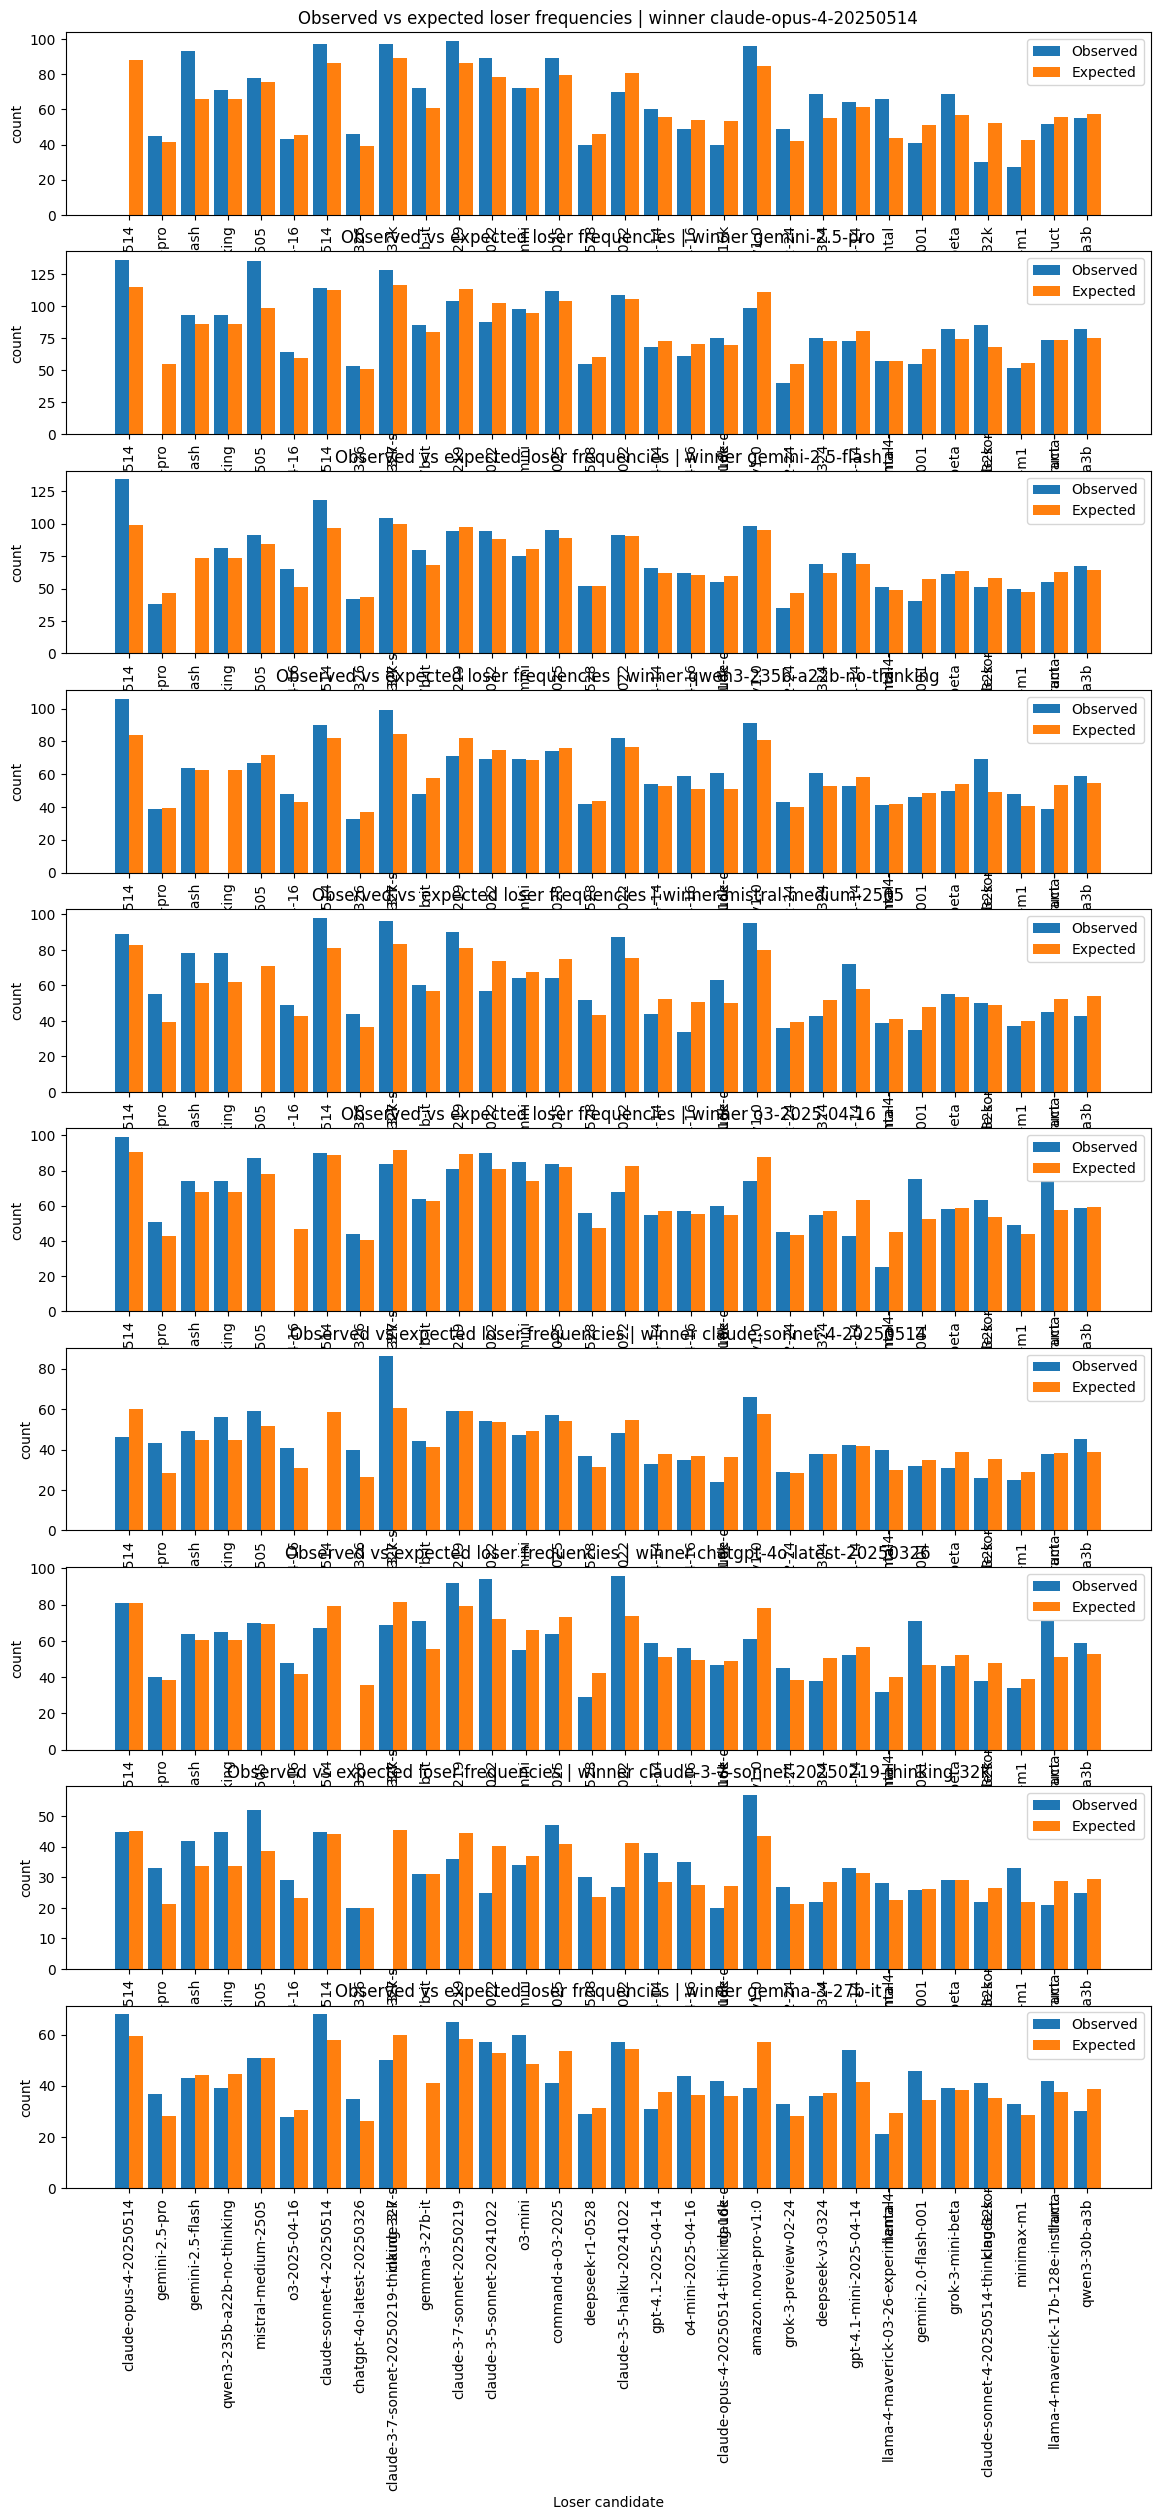

In [18]:
x = np.arange(observed.shape[1])
width = 0.42

fig, axes = plt.subplots(
    observed.shape[0],
    1,
    figsize=(14, max(3, 2.8 * observed.shape[0])),
    squeeze=False,
)

for row_idx, ax in enumerate(axes[:, 0]):
    ax.bar(x - width / 2, observed[row_idx], width=width, label='Observed')
    ax.bar(x + width / 2, expected[row_idx], width=width, label='Expected')
    ax.set_title(f'Observed vs expected loser frequencies | winner {observed_winner_labels[row_idx]}')
    ax.set_ylabel('count')
    ax.set_xticks(x)
    ax.set_xticklabels(observed_candidate_labels, rotation=90)
    ax.legend()

axes[-1, 0].set_xlabel('Loser candidate')
plt.tight_layout()
plt.show()


## Computing the conditional probability distributions

In [19]:
joint_counts = np.zeros(shape=(len(pw.candidate_distr), len(pw.candidate_distr)))
candidate_counts = np.zeros(shape=(len(pw.candidate_distr), ))
for p in range(len(pw.winners)):
    joint_counts[pw.winners[p], pw.losers[p]] += 1
    joint_counts[pw.losers[p], pw.winners[p]] += 1
    candidate_counts[pw.winners[p]] += 1
    candidate_counts[pw.losers[p]] += 1

In [20]:
joint_counts

array([[  0., 181., 227., 177., 167., 142., 143., 127., 142., 140., 120.,
        120., 113., 161., 120., 109., 131., 125.,  76., 141., 125., 135.,
        115., 148.,  84., 132.,  59.,  67.,  81., 108.],
       [181.,   0., 131., 132., 190., 115., 157.,  93., 161., 122., 137.,
        110., 123., 148., 100., 126.,  99.,  88., 105., 124.,  68., 110.,
        104., 107.,  68., 109., 126.,  82.,  94., 112.],
       [227., 131.,   0., 145., 169., 139., 167., 106., 146., 123., 140.,
        123., 102., 131., 113., 118., 105., 103.,  93., 131.,  66., 120.,
        108., 100.,  65.,  93.,  82.,  82.,  72.,  99.],
       [177., 132., 145.,   0., 145., 122., 146.,  98., 144.,  87., 109.,
         85., 104., 111., 108., 109.,  98.,  87., 116., 120., 103., 114.,
        105., 101.,  66.,  88., 111.,  91.,  58.,  95.],
       [167., 190., 169., 145.,   0., 136., 157., 114., 148., 111., 127.,
         88.,  99., 106., 117., 116.,  94.,  87., 102., 118.,  91.,  92.,
        124.,  92.,  66.,  96., 

In [21]:
joint_distr = np.zeros_like(joint_counts)
for r in range(len(joint_counts)):
    joint_distr[r, ...] = joint_counts[r, ...] / candidate_counts[r] # joint_counts[r, ...].sum() # candidate_counts[r]

In [22]:
for r in range(len(joint_counts)):
    print(joint_counts[r, ...].sum())
    print(candidate_counts[r])

3716.0
3716.0
3422.0
3422.0
3399.0
3399.0
3175.0
3175.0
3271.0
3271.0
2964.0
2964.0
3030.0
3030.0
2636.0
2636.0
2752.0
2752.0
2551.0
2551.0
2589.0
2589.0
2448.0
2448.0
2360.0
2360.0
2426.0
2426.0
2370.0
2370.0
2331.0
2331.0
2236.0
2236.0
2333.0
2333.0
2121.0
2121.0
2355.0
2355.0
2191.0
2191.0
2178.0
2178.0
2174.0
2174.0
2079.0
2079.0
2050.0
2050.0
2118.0
2118.0
1957.0
1957.0
1856.0
1856.0
1912.0
1912.0
1908.0
1908.0


In [23]:
joint_distr[0]

array([0.        , 0.04870829, 0.06108719, 0.04763186, 0.0449408 ,
       0.03821313, 0.03848224, 0.03417653, 0.03821313, 0.03767492,
       0.03229279, 0.03229279, 0.03040904, 0.04332616, 0.03229279,
       0.02933262, 0.03525296, 0.03363832, 0.0204521 , 0.03794403,
       0.03363832, 0.03632939, 0.03094726, 0.03982777, 0.02260495,
       0.03552207, 0.01587729, 0.01803014, 0.02179763, 0.02906351])

/tmp/ipykernel_3978789/3754164849.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


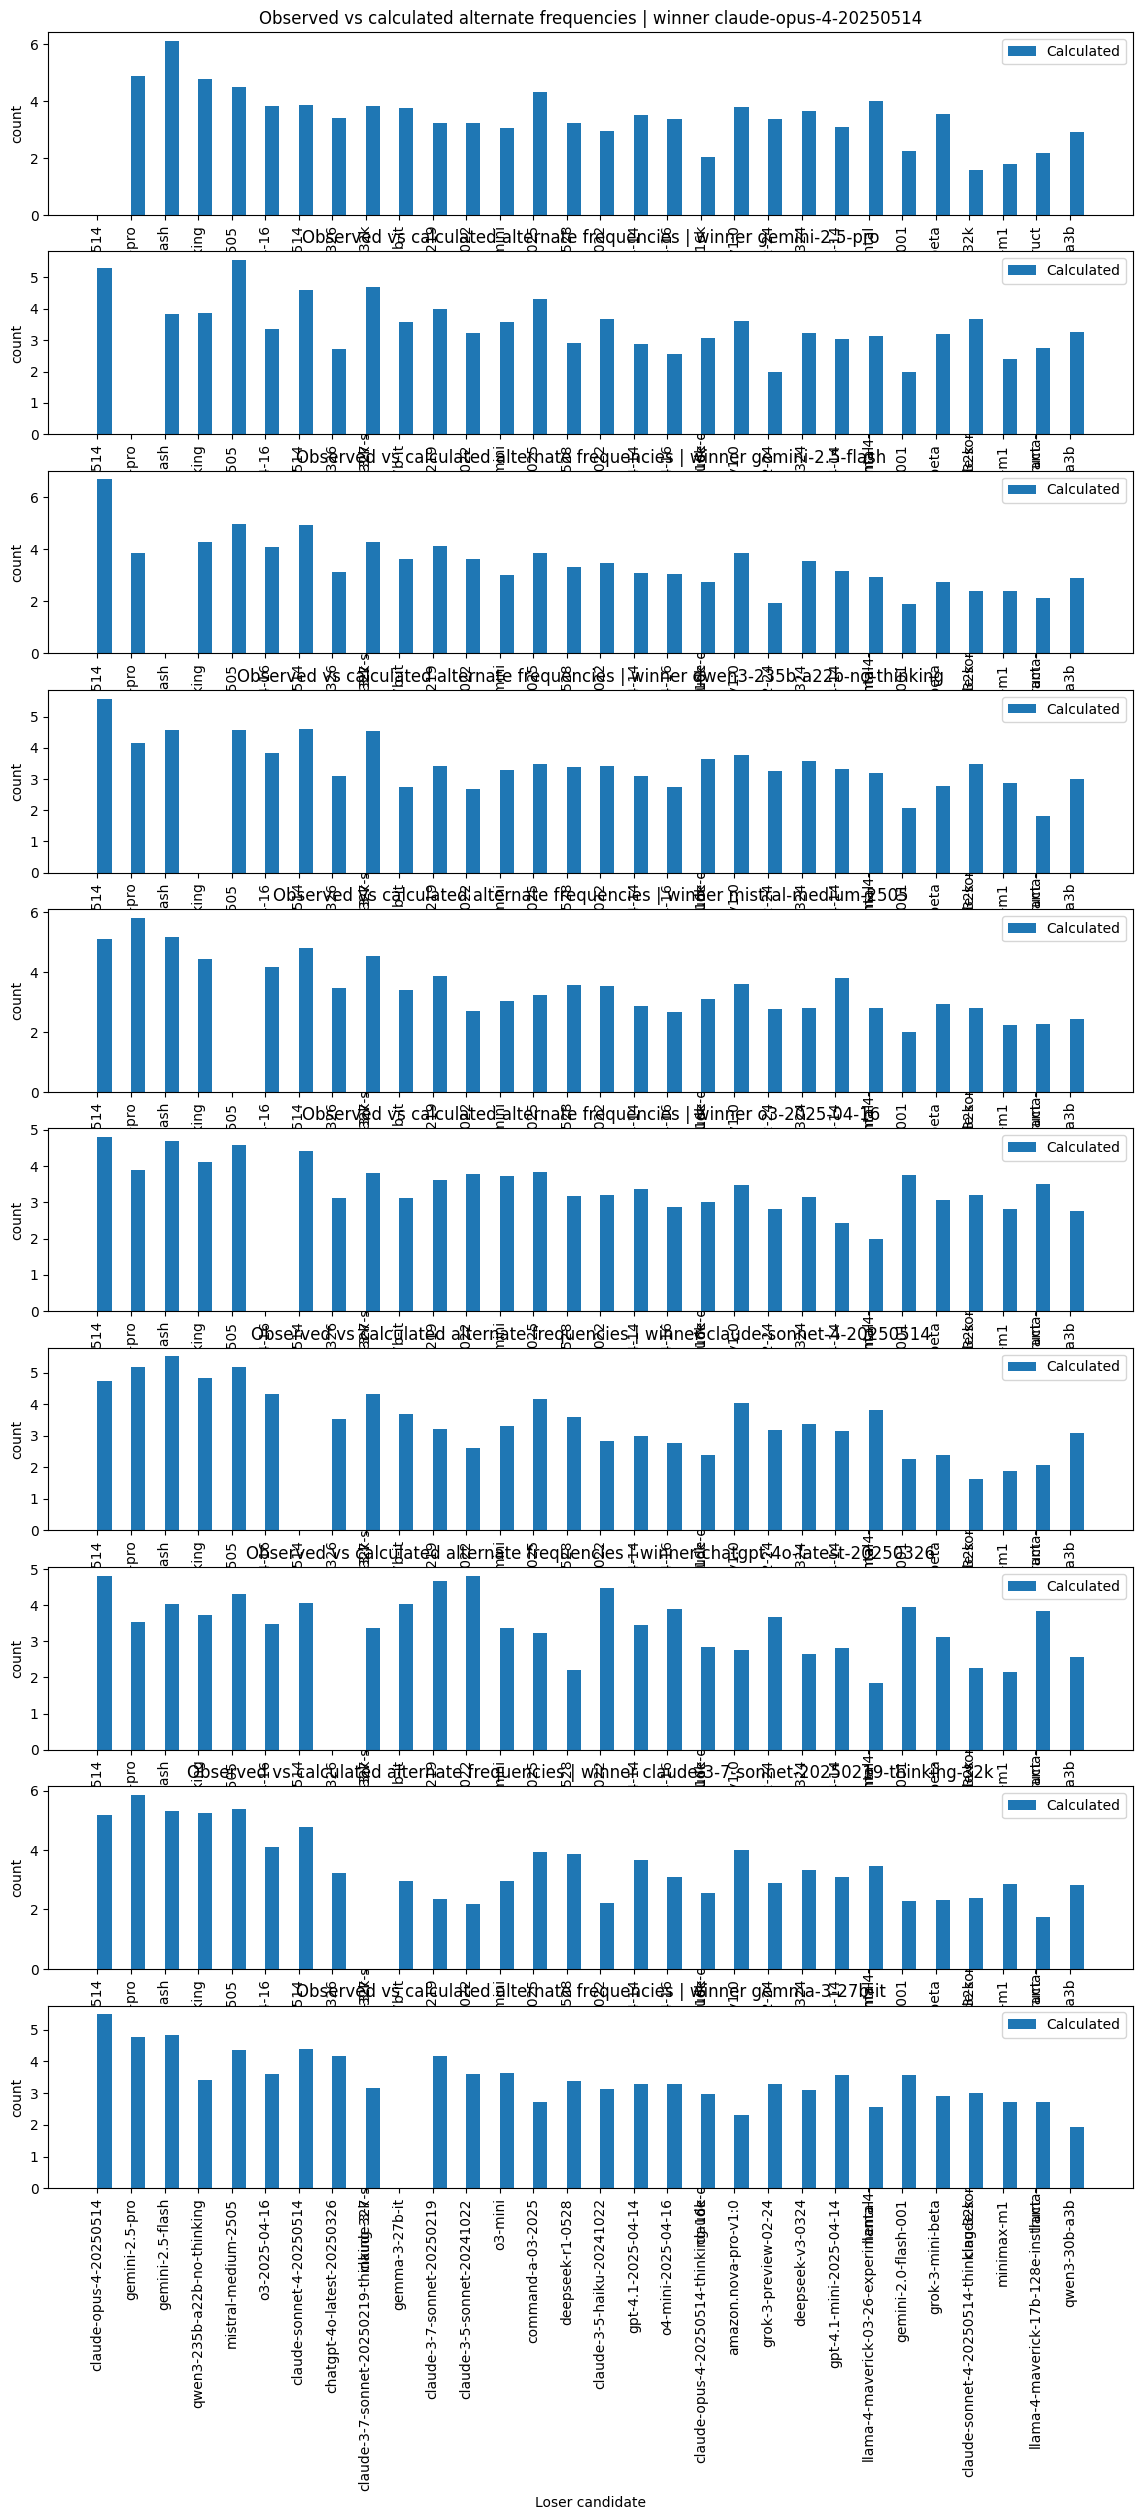

In [24]:
x = np.arange(observed.shape[1])
width = 0.42

fig, axes = plt.subplots(
    observed.shape[0],
    1,
    figsize=(14, max(3, 2.8 * observed.shape[0])),
    squeeze=False,
)

for row_idx, ax in enumerate(axes[:, 0]):
    # ax.bar(x - width / 2, observed[row_idx], width=width, label='Observed')
    ax.bar(x + width / 2, 100 * joint_distr[row_idx, ...], width=width, label='Calculated')
    ax.set_title(f'Observed vs calculated alternate frequencies | winner {observed_winner_labels[row_idx]}')
    ax.set_ylabel('count')
    ax.set_xticks(x)
    ax.set_xticklabels(observed_candidate_labels, rotation=90)
    ax.legend()

axes[-1, 0].set_xlabel('Loser candidate')
plt.tight_layout()
plt.show()


In [25]:
from scipy.special import expit

def borda_from_population_utilities(utilities, voter_dist=None, cand_dist=None, beta=1.0):
    utilities = np.asarray(utilities)
    V, C = utilities.shape

    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V
    else:
        voter_dist = np.asarray(voter_dist, dtype=float)
        assert voter_dist.shape == (V,)
        voter_dist = voter_dist / voter_dist.sum()

    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    else:
        cand_dist = np.asarray(cand_dist, dtype=float)
        # assert cand_dist.shape == (C,)
        # cand_dist = cand_dist / cand_dist.sum()

    P = np.zeros((C, C), dtype=float)

    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)

    np.fill_diagonal(P, 0.0) # remove this?
    borda_scores = (P * cand_dist).sum(axis=1) # (m, m) @ (m, ...)
    ranking = np.argsort(-borda_scores)

    return borda_scores, ranking

In [26]:
from utils_3 import leaderboard_dist

In [27]:
true_ranking = np.argsort(-population.avg_utilities)

[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 25 18  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7  5 20 14 23  2  3 16 21  4 17 27  0 18 25  9 22 26 24 29 13  6 12
 28  8 11 10 19 15]
[ 1  7 20  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1 20  7  5 14 23  2  3 16 21  4 17  0 27 18 25  9 22 26 24 29 13  6 12
  8 28 11 10 19 15]
[ 1  7 20  5 14  2 23  3 16 21  4 17  0 27 18 25  9 22 24 26 29 13  6 12
  8 28 11 10 19 15]


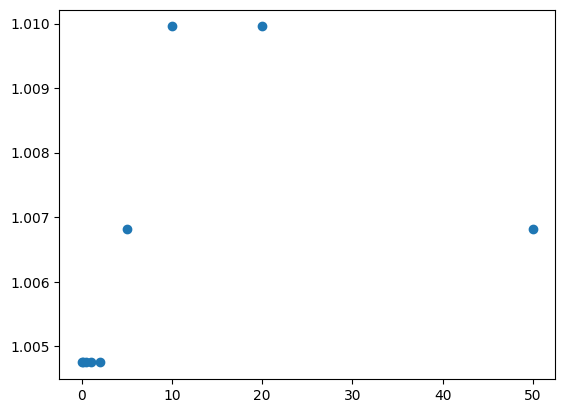

In [28]:
betas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]
leaderboard_distortions = []

print(true_ranking)

for beta in betas:
    borda_scores, borda_ranking = borda_from_population_utilities(utilities=population.population_utilities, voter_dist=population.voter_distr, cand_dist=joint_distr, beta=beta)
    print(borda_ranking)
    distortion, k = leaderboard_dist(borda_ranking, true_ranking, population.avg_utilities)
    leaderboard_distortions.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(leaderboard_distortions))
plt.show()

In [29]:
leaderboard_distortions

[np.float64(1.0047482962757752),
 np.float64(1.0047482962757752),
 np.float64(1.0047482962757752),
 np.float64(1.0047482962757752),
 np.float64(1.0047482962757752),
 np.float64(1.006811056502588),
 np.float64(1.0099553753099328),
 np.float64(1.0099553753099328),
 np.float64(1.006811056502588)]

| Beta | Kendall tau | Spearman footrule | Hamming |
| --------- | ----------- | ----------------- | ------- |
| true         | 0           | 0                 | 0       |
| 0.01         | 4           | 8                 | 4       |
| 0.1         | 4           | 8                 | 4       |
| 0.5         | 4           | 8                 | 4       |
| 1.0         | 6           | 12                | 6       |
| 2.0         | 9           | 18                | 8       |
| 5.0         | 11          | 22                | 10      |
| 10.0         | 13          | 26                | 12      |
| 20.0         | 17          | 34                | 14      |
| 50.0        | 17          | 34                | 14      |


In [30]:
[0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]

[0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]

## Trying a fixed weight set

In [31]:
fixed_weight_set = 2 * np.ones_like(true_ranking) ** np.arange(len(true_ranking))

In [33]:
pw.candidates_to_idx

{np.str_('claude-opus-4-20250514'): 0,
 np.str_('gemini-2.5-pro'): 1,
 np.str_('gemini-2.5-flash'): 2,
 np.str_('qwen3-235b-a22b-no-thinking'): 3,
 np.str_('mistral-medium-2505'): 4,
 np.str_('o3-2025-04-16'): 5,
 np.str_('claude-sonnet-4-20250514'): 6,
 np.str_('chatgpt-4o-latest-20250326'): 7,
 np.str_('claude-3-7-sonnet-20250219-thinking-32k'): 8,
 np.str_('gemma-3-27b-it'): 9,
 np.str_('claude-3-7-sonnet-20250219'): 10,
 np.str_('claude-3-5-sonnet-20241022'): 11,
 np.str_('o3-mini'): 12,
 np.str_('command-a-03-2025'): 13,
 np.str_('deepseek-r1-0528'): 14,
 np.str_('claude-3-5-haiku-20241022'): 15,
 np.str_('gpt-4.1-2025-04-14'): 16,
 np.str_('o4-mini-2025-04-16'): 17,
 np.str_('claude-opus-4-20250514-thinking-16k'): 18,
 np.str_('amazon.nova-pro-v1:0'): 19,
 np.str_('grok-3-preview-02-24'): 20,
 np.str_('deepseek-v3-0324'): 21,
 np.str_('gpt-4.1-mini-2025-04-14'): 22,
 np.str_('llama-4-maverick-03-26-experimental'): 23,
 np.str_('gemini-2.0-flash-001'): 24,
 np.str_('grok-3-mini-be

In [34]:
'gemini-2.5-flash-preview-04-17' in list(pw.candidates_to_idx.keys())

False

In [43]:
ds['train']['winner'][61586]

'model_b'